# How to compute a functional map between two graphs?

In [14]:
import gsops.backend as gs
import numpy as np
import scipy.sparse

from geomfum.convert import P2pFromFmConverter
from geomfum.descriptor.pipeline import (
    ArangeSubsampler,
    DescriptorPipeline,
    L2InnerNormalizer,
)
from geomfum.descriptor.spectral import WaveKernelSignature, LandmarkHeatKernelSignature
from geomfum.functional_map import (
    FactorSum,
    LBCommutativityEnforcing,
    OperatorCommutativityEnforcing,
    SpectralDescriptorPreservation,
)
from geomfum.numerics.optimization import ScipyMinimize
from geomfum.shape import Graph

## Create two graphs

We create two cycle graphs (ring graphs) with the same number of vertices. The adjacency matrix is built with `scipy.sparse` and then converted to the `gsops` sparse format.

In [71]:
import numpy as np
import scipy.sparse


def build_grid_adjacency(n):
    """4-neighbor grid adjacency matrix for n x n grid."""
    N = n * n
    rows, cols = [], []

    def idx(i, j):
        return i * n + j

    for i in range(n):
        for j in range(n):
            if i + 1 < n:
                rows += [idx(i, j), idx(i + 1, j)]
                cols += [idx(i + 1, j), idx(i, j)]
            if j + 1 < n:
                rows += [idx(i, j), idx(i, j + 1)]
                cols += [idx(i, j + 1), idx(i, j)]

    data = np.ones(len(rows))
    return scipy.sparse.csc_matrix((data, (rows, cols)), shape=(N, N))


def make_grid_points(n):
    x, y = np.meshgrid(np.arange(n), np.arange(n))
    return np.vstack([x.ravel(), y.ravel()]).T


def warp_points(points, strength=0.4):
    """Gentler smooth deformation → closer to isometry."""
    warped = points.copy().astype(float)
    warped[:, 0] += strength * np.sin(points[:, 1] / 3)
    warped[:, 1] += strength * np.sin(points[:, 0] / 3)
    return warped


# -----------------------
# Parameters
# -----------------------
n_side = 10  # 100 nodes

# -----------------------
# SAME adjacency for both
# -----------------------
adj = build_grid_adjacency(n_side)

# -----------------------
# Different embeddings
# -----------------------
pts_a = make_grid_points(n_side)
pts_b = warp_points(pts_a, strength=0.4)  # smaller warp = more isometric

# -----------------------
# Graph objects (same connectivity!)
# -----------------------
graph_a = Graph(adjacency_matrix=gs.sparse.from_scipy_csc(adj))
graph_b = Graph(adjacency_matrix=gs.sparse.from_scipy_csc(adj.copy()))

graph_a.landmark_indices = [0, 22, 55, 99]
graph_b.landmark_indices = [0, 22, 55, 99]

print(graph_a.n_vertices, graph_b.n_vertices)


100 100


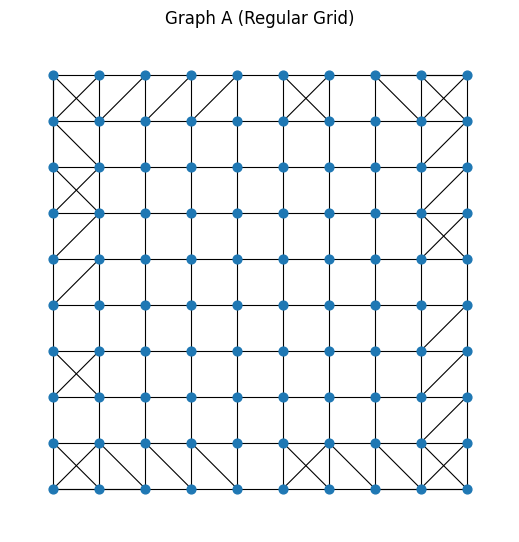

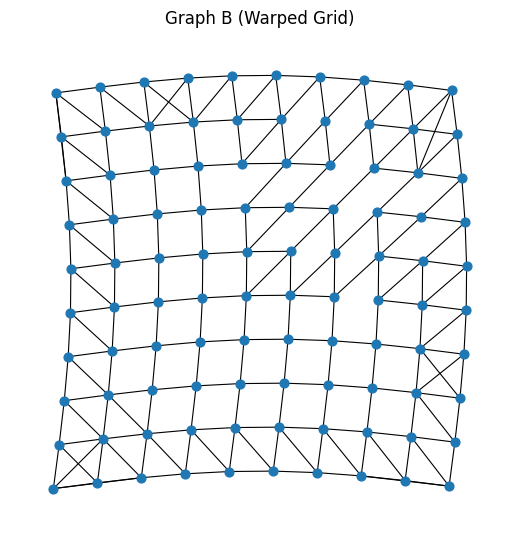

In [72]:
# visualize
import matplotlib.pyplot as plt
import networkx as nx


def nx_from_adj(adj):
    """Convert scipy sparse adjacency to NetworkX graph."""
    return nx.from_scipy_sparse_array(adj)


def plot_graph(G, positions, title="Graph"):
    plt.figure(figsize=(5, 5))
    nx.draw(
        G,
        pos={i: positions[i] for i in range(len(positions))},
        node_size=40,
        width=0.8,
        with_labels=False,
    )
    plt.title(title)
    plt.axis("equal")
    plt.show()


# Convert to NetworkX
G_a_nx = nx_from_adj(adj_a)
G_b_nx = nx_from_adj(adj_b)

# Plot
plot_graph(G_a_nx, pts_a, "Graph A (Regular Grid)")
plot_graph(G_b_nx, pts_b, "Graph B (Warped Grid)")


## Compute Laplacian spectrum

Compute the Laplacian eigenbasis for each graph. The graph Laplacian $L = D - W$ is used automatically when the shape type is `"graph"`.

In [84]:
graph_a.laplacian.find_spectrum(spectrum_size=99, set_as_basis=True, recompute=True)
graph_b.laplacian.find_spectrum(spectrum_size=99, set_as_basis=True, recompute=True)

graph_a.basis.vals

array([-5.20417043e-18,  2.85980083e-02,  2.85980083e-02,  6.03073792e-02,
        1.10476584e-01,  1.10476584e-01,  1.46555405e-01,  1.46555405e-01,
        2.33955557e-01,  2.34979020e-01,  2.34979020e-01,  2.77186292e-01,
        2.77186292e-01,  3.66593030e-01,  3.66593030e-01,  3.87061781e-01,
        3.87061781e-01,  4.35734867e-01,  4.35734867e-01,  5.00000000e-01,
        5.28487860e-01,  5.28487860e-01,  5.49546864e-01,  5.49546864e-01,
        6.03741128e-01,  6.03741128e-01,  6.62976719e-01,  6.62976719e-01,
        7.00261825e-01,  7.00261825e-01,  7.05141596e-01,  7.05141596e-01,
        7.63253690e-01,  7.63253690e-01,  8.26351822e-01,  8.36271074e-01,
        8.36271074e-01,  8.38608756e-01,  8.38608756e-01,  8.62785420e-01,
        8.62785420e-01,  8.98941633e-01,  8.98941633e-01,  9.38853553e-01,
        9.38853553e-01,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  

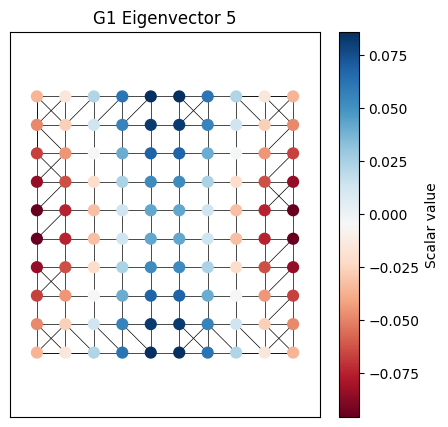

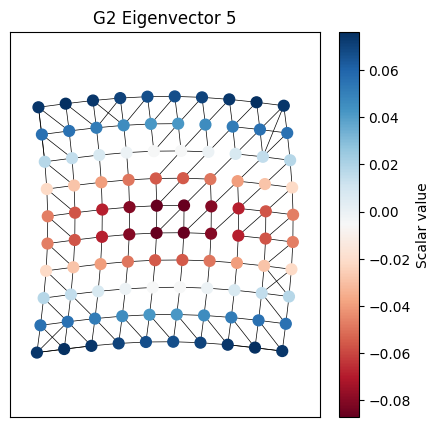

In [85]:
def plot_scalar_on_graph(G, positions, values, title="Scalar Function", cmap="RdBu"):
    plt.figure(figsize=(5, 5))

    nodes = nx.draw_networkx_nodes(
        G,
        pos={i: positions[i] for i in range(len(positions))},
        node_size=60,
        node_color=values,
        cmap=cmap,
    )
    nx.draw_networkx_edges(
        G, pos={i: positions[i] for i in range(len(positions))}, width=0.5
    )

    plt.colorbar(nodes, label="Scalar value")
    plt.title(title)
    plt.axis("equal")
    plt.show()


k = 5
plot_scalar_on_graph(G_a_nx, pts_a, graph_a.basis.vecs[:, k], f"G1 Eigenvector {k}")
plot_scalar_on_graph(G_b_nx, pts_b, graph_b.basis.vecs[:, k], f"G2 Eigenvector {k}")


## Compute descriptors

Use the same descriptor pipeline as for meshes. HKS and WKS are defined purely in terms of the Laplacian eigenvalues and eigenvectors, so they work on any shape type.

In [86]:
steps = [
    LandmarkHeatKernelSignature.from_registry(n_domain=100),
    ArangeSubsampler(subsample_step=2),
    WaveKernelSignature.from_registry(n_domain=100),
    L2InnerNormalizer(),
]

pipeline = DescriptorPipeline(steps)

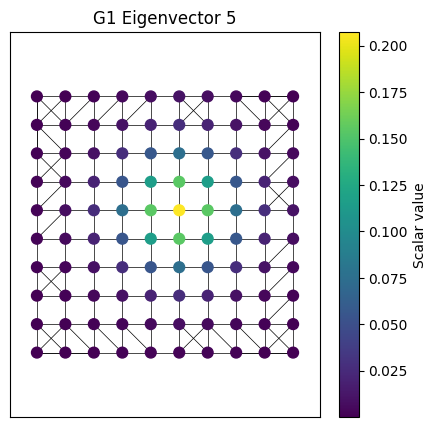

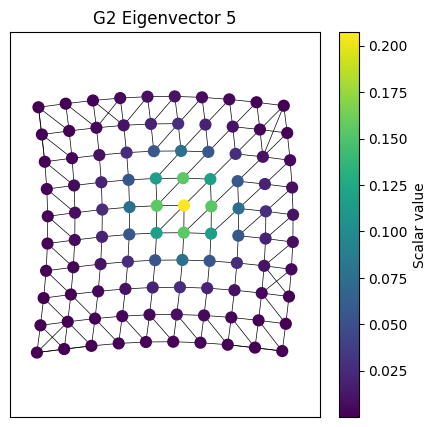

In [87]:
descr_a = pipeline.apply(graph_a)
descr_b = pipeline.apply(graph_b)

descr_a.shape, descr_b.shape


n = 100
plot_scalar_on_graph(G_a_nx, pts_a, descr_a[n], f"G1 Eigenvector {k}", cmap="viridis")
plot_scalar_on_graph(G_b_nx, pts_b, descr_b[n], f"G2 Eigenvector {k}", cmap="viridis")


## Build functional map objective

We use three types of constraints:
1. **SpectralDescriptorPreservation**: align spectral descriptor coefficients.
2. **LBCommutativityEnforcing**: commute with the Laplacian.
3. **OperatorCommutativityEnforcing (multiplication)**: commute with descriptor multiplication operators.

Note: `OperatorCommutativityEnforcing.from_orientation` is not available for graphs since it requires face-valued gradient operators, which are specific to triangle meshes.

In [95]:
factors = [
    SpectralDescriptorPreservation(
        graph_a.basis.project(descr_a),
        graph_b.basis.project(descr_b),
        weight=1.0,
    ),
    LBCommutativityEnforcing.from_bases(
        graph_a.basis,
        graph_b.basis,
        weight=1e-2,
    ),
    OperatorCommutativityEnforcing.from_multiplication(
        graph_a.basis, descr_a, graph_b.basis, descr_b, weight=1e-1
    ),
]
graph_a.basis.use_k = 20
graph_b.basis.use_k = 20
objective = FactorSum(factors)

## Optimize the functional map

In [96]:
optimizer = ScipyMinimize(method="L-BFGS-B")

x0 = gs.zeros((graph_b.basis.use_k, graph_a.basis.use_k))

res = optimizer.minimize(
    objective,
    x0,
    fun_jac=objective.gradient,
)

fmap = res.x.reshape(x0.shape)

fmap.shape

(20, 20)

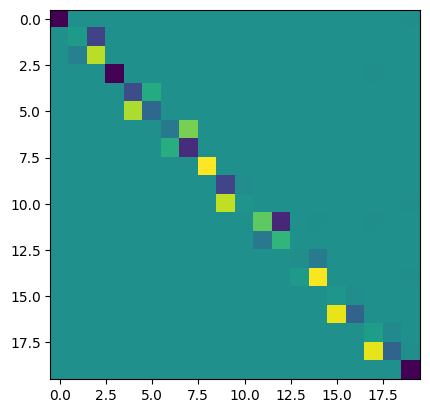

In [97]:
import matplotlib.pyplot as plt

plt.imshow(fmap)

## Convert to pointwise map

In [98]:
p2p_converter = P2pFromFmConverter()

p2p = p2p_converter(fmap, graph_a.basis, graph_b.basis)

p2p.shape

(100,)

## Further reading

* [How to compute a functional map?](./07_functional_map.ipynb)
* [How to compute a pointwise map from a functional map?](./10_pointwise_from_functional.ipynb)